# Feature Preparation and Pre-modeling Diagnostics

In [1]:
# ============================================================
# RETROVIRAL WALL CHALLENGE
# NOTEBOOK 2: MODELING
# STAGE 0 - FEATURE PREPARATION AND PRE-MODELING DIAGNOSTICS
# ============================================================
# Este bloque:
# 1) carga los datos base
# 2) reconstruye los bloques biológicos
# 3) calcula métricas de sesgo por familia
# 4) calcula señal global e intra-familia
# 5) hace pruning por redundancia
# 6) construye feature sets finales para modelamiento
#
# Perspectiva bioinformática:
# queremos distinguir entre:
# - features que parecen útiles porque capturan parentesco evolutivo
# - features que parecen útiles porque reflejan función mecanística
#
# Perspectiva ML:
# queremos llegar al baseline LOFO con feature sets limpios,
# interpretables y menos redundantes.
# ============================================================

import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from scipy.stats import spearmanr, kruskal

from catboost import CatBoostClassifier, CatBoostRegressor
from scipy.stats import rankdata

# ------------------------------------------------------------
# Configuración visual y de pandas
# ------------------------------------------------------------
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Setup listo.")

Setup listo.


# 1) Paths y carga de archivos

In [2]:
# ============================================================
# 1. PATHS Y CARGA DE DATOS
# ============================================================
# Usamos los mismos datasets del notebook de EDA principal.
# Esto permite que el notebook de modelamiento sea autocontenible
# y no dependa de variables creadas en otro notebook.
# ============================================================

TRAIN_DIR = "/kaggle/input/datasets/damontoyat/retroviral-train"
FAMILY_DIR = "/kaggle/input/datasets/damontoyat/retroviral-family-splits"
FEAT_DICT_DIR = "/kaggle/input/datasets/damontoyat/retroviral-feature-dic"
TEST_DIR = "/kaggle/input/datasets/damontoyat/retroviral-test"

train_path = os.path.join(TRAIN_DIR, "train.csv")
family_path = os.path.join(FAMILY_DIR, "family_splits.csv")
feat_dict_path = os.path.join(FEAT_DICT_DIR, "feature_dictionary.csv")

train_df = pd.read_csv(train_path)
family_df = pd.read_csv(family_path)
feat_dict_df = pd.read_csv(feat_dict_path)

print("train_df shape:", train_df.shape)
print("family_df shape:", family_df.shape)
print("feat_dict_df shape:", feat_dict_df.shape)

display(train_df.head(3))

train_df shape: (57, 71)
family_df shape: (7, 5)
feat_dict_df shape: (66, 2)


,rt_name,sequence,active,pe_efficiency_pct,protein_length_aa,perplexity,instability_index,gravy,t40_raw,t45_raw,t50_raw,t55_raw,t60_raw,t65_raw,t70_raw,t75_raw,t80_raw,thermophilicity_num,triad_found_bin,D1_D2_dist,D2_D3_dist,triad_best_rmsd,hydrophobic_per_res,salt_per_res,hbonds_per_res,pocket_hydrophobic_per_res,pocket_hbonds_per_res,whole_mean_hydrophobicity,whole_std_hydrophobicity,yxdd_hydrophobic_fraction,yxdd_mean_hydrophobicity,hairpin_pass,yxdd_y_is_strand,yxdd_x_is_turn,yxdd_d1_is_turn,yxdd_d2_is_strand,foldseek_best_TM,foldseek_best_LDDT,foldseek_best_fident,foldseek_TM_HIV1,foldseek_TM_MMLV,foldseek_TM_MMLVPE,foldseek_TM_Retron,foldseek_TM_LTRRetrotransposon,foldseek_TM_Group2Intron,foldseek_TM_Telomerase,seq_length,log_likelihood,net_charge,camsol,helix_beta_ratio,yxdd_std_hydrophobicity,n_residues,sasa_per_res,apolar_ratio,mean_rsasa,pocket_mean_rsasa,nterm_avg_sasa,rama_fav,rama_out,hairpin_confidence,yxdd_seq,overall_mean_pot,fingers_mean_pot,motif12_mean_pot,lpqg_sp_3A_mean_pot,yxdd_5A_mean_pot,palm_mean_pot,thumb_mean_pot,connection_mean_pot,rt_family
0,A.platensis-Cas1-RT,GDALLAAWYQVRTRSKTAGIDGISVELFAHFLDEELKRLAHQLQQD...,0,0.0,278,7.073275,41.651835,0.011871,0.8797,0.8276,0.82280,0.81430,0.49260,0.1954,0.130900,0.079320,0.033450,2,1.0,11.5889,3.8325,7.4584,0.586,0.0216,1.565,0.409,0.545,0.0119,3.1276,0.6667,1.2889,1,1.0,1.0,1.0,1.0,0.9380,0.7883,0.281,0.7081,0.6936,0.6689,0.8251,0.5711,0.9380,0.8278,278,-1.956324,-3,0.277500,0.758621,2.8154,278.0,53.797554,0.537,0.2728,0.0918,117.61,94.7,0.0,0.727,YGDD,-2.0977,2.3503,13.7854,5.0225,-8.1501,-7.3936,-6.1497,NaN,CRISPR-associated
1,CRISPRRT2-RT,ISSQFIDINNFQRAWEKVADKRGCAGVDGETISSFASNQTVNVYQL...,0,0.0,319,5.294906,29.598746,-0.215987,0.2064,0.1278,0.06472,0.04293,0.01897,0.0133,0.004877,0.002055,0.000511,0,1.0,14.9349,3.8714,9.4629,0.552,0.0219,1.542,0.478,0.478,-0.2160,3.2503,0.6842,1.2947,1,1.0,1.0,1.0,1.0,0.9155,0.7941,0.248,0.6902,0.6958,0.5897,0.8520,0.5512,0.9155,0.7676,319,-1.666745,4,0.533760,0.701613,2.7820,319.0,57.389655,0.538,0.2860,0.1039,111.41,91.0,0.3,0.664,YADD,1.6170,4.1130,14.7995,19.3829,-8.8022,-5.7010,13.9471,NaN,CRISPR-associated
2,FuRT-Cas1-RT,HVSELEKYWRMNHDQIISDLKNQEYQPGIILIREHMNKTGKRRNIA...,0,0.0,240,8.801058,44.682917,-0.371250,0.5879,0.5006,0.51240,0.62900,0.63860,0.2500,0.238700,0.155700,0.017130,2,0.0,NaN,NaN,NaN,0.467,0.0292,1.550,0.000,0.000,-0.3713,3.2801,NaN,NaN,1,0.0,0.0,0.0,0.0,0.9591,0.8716,0.315,0.7017,0.6888,0.7105,0.8485,0.6740,0.9591,0.8070,240,-2.174872,-2,1.013978,0.814433,NaN,240.0,57.662042,0.529,0.2760,0.0000,112.56,95.5,0.4,0.659,NaN,-0.1282,2.3308,12.4422,10.9865,NaN,-2.5362,NaN,NaN,CRISPR-associated


# 2) Definir columnas base

In [3]:
# ============================================================
# 2. COLUMNAS BASE
# ============================================================
# Separamos explícitamente:
# - IDs y metadata biológica
# - targets
# - features numéricas candidatas
# ============================================================

ID_COL = "rt_name"
SEQ_COL = "sequence"
FAMILY_COL = "rt_family"

TARGET_CLASS = "active"
TARGET_REG = "pe_efficiency_pct"

BASE_NON_FEATURE_COLS = [ID_COL, SEQ_COL, FAMILY_COL, TARGET_CLASS, TARGET_REG]

numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols_all_numeric = [c for c in numeric_cols if c not in [TARGET_CLASS, TARGET_REG]]

print("Número total de columnas:", train_df.shape[1])
print("Número de columnas numéricas:", len(numeric_cols))
print("Número de features numéricas candidatas:", len(feature_cols_all_numeric))

Número total de columnas: 71
Número de columnas numéricas: 67
Número de features numéricas candidatas: 65


# 3) Reconstruir bloques biológicos

In [4]:
# ============================================================
# 3. BLOQUES BIOLOGICOS
# ============================================================
# Agrupamos features por rol biológico aproximado.
# Esto servirá luego para:
# - ablaciones por bloque
# - interpretar qué grupo generaliza mejor
# - comparar señal mecanística vs señal filogenética
# ============================================================

all_cols = train_df.columns.tolist()

block_dict = {
    "metadata_global": sorted(list(set([
        c for c in all_cols
        if c in ["protein_length_aa", "seq_length", "n_residues", "resolved_residues"]
    ]))),
    
    "catalitico_triada_yxdd_hairpin": sorted(list(set([
        c for c in all_cols
        if (
            ("triad" in c.lower()) or
            ("yxdd" in c.lower()) or
            ("hairpin" in c.lower()) or
            (c in ["D1_D2_dist", "D2_D3_dist"])
        )
    ]))),
    
    "hidrofobicidad_y_superficie": sorted(list(set([
        c for c in all_cols
        if (
            ("hydrophobic" in c.lower()) or
            ("gravy" in c.lower()) or
            ("sasa" in c.lower()) or
            ("rsasa" in c.lower()) or
            ("hbonds" in c.lower()) or
            ("pocket_" in c.lower())
        )
    ]))),
    
    "electrostatica_local": sorted(list(set([
        c for c in all_cols
        if (
            ("mean_pot" in c.lower()) or
            ("overall_mean_pot" in c.lower()) or
            ("palm_mean_pot" in c.lower()) or
            ("fingers_mean_pot" in c.lower()) or
            ("thumb_mean_pot" in c.lower()) or
            ("motif12_mean_pot" in c.lower()) or
            ("lpqg_sp_3a_mean_pot" in c.lower()) or
            ("net_charge" in c.lower())
        )
    ]))),
    
    "estabilidad_termo": sorted(list(set([
        c for c in all_cols
        if (
            ("t40" in c.lower()) or
            ("t45" in c.lower()) or
            ("t50" in c.lower()) or
            ("t55" in c.lower()) or
            ("t60" in c.lower()) or
            ("t65" in c.lower()) or
            ("t70" in c.lower()) or
            ("t75" in c.lower()) or
            ("t80" in c.lower()) or
            ("thermo" in c.lower()) or
            ("instability" in c.lower()) or
            ("camsol" in c.lower())
        )
    ]))),
    
    "similitud_estructural_foldseek": sorted(list(set([
        c for c in all_cols
        if "foldseek" in c.lower()
    ]))),
    
    "modelo_secuencia_global": sorted(list(set([
        c for c in all_cols
        if (
            ("log_likelihood" in c.lower()) or
            ("perplexity" in c.lower())
        )
    ]))),
}

for block_name, cols in block_dict.items():
    print(f"{block_name}: {len(cols)} columnas")
    print(cols[:12], "..." if len(cols) > 12 else "")
    print("-" * 80)

metadata_global: 3 columnas
['n_residues', 'protein_length_aa', 'seq_length'] 
--------------------------------------------------------------------------------
catalitico_triada_yxdd_hairpin: 15 columnas
['D1_D2_dist', 'D2_D3_dist', 'hairpin_confidence', 'hairpin_pass', 'triad_best_rmsd', 'triad_found_bin', 'yxdd_5A_mean_pot', 'yxdd_d1_is_turn', 'yxdd_d2_is_strand', 'yxdd_hydrophobic_fraction', 'yxdd_mean_hydrophobicity', 'yxdd_seq'] ...
--------------------------------------------------------------------------------
hidrofobicidad_y_superficie: 14 columnas
['gravy', 'hbonds_per_res', 'hydrophobic_per_res', 'mean_rsasa', 'nterm_avg_sasa', 'pocket_hbonds_per_res', 'pocket_hydrophobic_per_res', 'pocket_mean_rsasa', 'sasa_per_res', 'whole_mean_hydrophobicity', 'whole_std_hydrophobicity', 'yxdd_hydrophobic_fraction'] ...
--------------------------------------------------------------------------------
electrostatica_local: 9 columnas
['connection_mean_pot', 'fingers_mean_pot', 'lpqg_sp_3A_m

# 4) Funciones auxiliares

In [5]:
# ============================================================
# 4. FUNCIONES AUXILIARES
# ============================================================

def get_numeric_cols(df, cols):
    """Devuelve solo columnas numéricas existentes en el dataframe."""
    return [c for c in cols if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]


def safe_spearman(df, feature, target):
    """
    Calcula Spearman de forma segura.
    Devuelve NaN si no hay suficiente variación o datos.
    """
    x = df[[feature, target]].dropna()
    if len(x) < 3:
        return np.nan
    if x[feature].nunique() < 2 or x[target].nunique() < 2:
        return np.nan
    corr, _ = spearmanr(x[feature], x[target])
    return corr


def within_family_spearman(df, feature, target, family_col=FAMILY_COL, min_n=3):
    """
    Calcula Spearman dentro de cada familia y luego promedia.
    
    Esto es útil porque una feature puede verse muy fuerte globalmente
    solo porque separa familias. Si además conserva señal dentro de familia,
    eso sugiere una relación más mecanística y potencialmente más robusta
    para LOFO.
    """
    vals = []
    
    subset = df[[family_col, feature, target]].dropna()
    for fam, g in subset.groupby(family_col):
        if len(g) < min_n:
            continue
        if g[feature].nunique() < 2 or g[target].nunique() < 2:
            continue
        
        corr, _ = spearmanr(g[feature], g[target])
        if pd.notna(corr):
            vals.append(corr)
    
    if len(vals) == 0:
        return np.nan
    
    return float(np.mean(vals))


def standardized_family_bias_score(df, feature, family_col=FAMILY_COL):
    """
    Score estandarizado de sesgo por familia:
    (max media por familia - min media por familia) / std global
    
    Sirve para comparar features en distintas escalas numéricas.
    """
    x = df[[family_col, feature]].dropna()
    if len(x) < 3:
        return np.nan
    
    global_std = x[feature].std()
    if pd.isna(global_std) or global_std == 0:
        return np.nan
    
    means = x.groupby(family_col)[feature].mean()
    return float((means.max() - means.min()) / global_std)


def eta_squared_by_family(df, feature, family_col=FAMILY_COL):
    """
    Eta-squared aproximado:
    proporción de varianza explicada por familia.
    
    Alto eta² -> la familia explica gran parte de la variación de la feature.
    """
    x = df[[family_col, feature]].dropna()
    if len(x) < 3:
        return np.nan
    
    grand_mean = x[feature].mean()
    groups = [g[feature].values for _, g in x.groupby(family_col)]
    if len(groups) < 2:
        return np.nan
    
    ss_between = sum(len(g) * (np.mean(g) - grand_mean) ** 2 for g in groups)
    ss_total = sum((x[feature] - grand_mean) ** 2)
    
    if ss_total == 0:
        return np.nan
    
    return float(ss_between / ss_total)


def safe_kruskal_by_family(df, feature, family_col=FAMILY_COL):
    """
    Kruskal-Wallis por familia.
    No será criterio principal, pero ayuda como diagnóstico adicional.
    """
    x = df[[family_col, feature]].dropna()
    groups = [g[feature].values for _, g in x.groupby(family_col) if len(g) > 0]
    
    if len(groups) < 2:
        return np.nan, np.nan
    
    try:
        stat, p = kruskal(*groups)
        return float(stat), float(p)
    except Exception:
        return np.nan, np.nan


def correlation_pruning(df, feature_list, threshold=0.95, prefer_df=None):
    """
    Elimina redundancia por correlación absoluta.
    
    Si dos features están muy correlacionadas, se conserva la que
    tenga mejor generalization_score (si prefer_df está disponible).
    """
    feature_list = [f for f in feature_list if f in df.columns]
    feature_list = [f for f in feature_list if pd.api.types.is_numeric_dtype(df[f])]
    
    if len(feature_list) <= 1:
        return feature_list, pd.DataFrame(columns=["keep", "drop", "corr"])
    
    corr = df[feature_list].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    
    to_drop = set()
    decisions = []
    
    score_map = {}
    if prefer_df is not None and {"feature", "generalization_score"}.issubset(prefer_df.columns):
        score_map = prefer_df.set_index("feature")["generalization_score"].to_dict()
    
    for col in upper.columns:
        highly_corr = upper.index[upper[col] > threshold].tolist()
        
        for row_feat in highly_corr:
            if row_feat in to_drop or col in to_drop:
                continue
            
            keep_feat, drop_feat = row_feat, col
            
            if len(score_map) > 0:
                s_row = score_map.get(row_feat, -np.inf)
                s_col = score_map.get(col, -np.inf)
                if s_col > s_row:
                    keep_feat, drop_feat = col, row_feat
            
            to_drop.add(drop_feat)
            decisions.append({
                "keep": keep_feat,
                "drop": drop_feat,
                "corr": float(upper.loc[row_feat, col])
            })
    
    kept = [f for f in feature_list if f not in to_drop]
    decision_df = pd.DataFrame(decisions).sort_values("corr", ascending=False) if len(decisions) > 0 else pd.DataFrame(columns=["keep", "drop", "corr"])
    
    return kept, decision_df

# 5) Tabla maestra de features

In [6]:
# ============================================================
# 5. TABLA MAESTRA DE FEATURES
# ============================================================
# Esta tabla resume, para cada feature:
# - señal global con actividad
# - señal global con eficiencia
# - señal intra-familia
# - sesgo por familia
# - missing
# - variabilidad
#
# Es la base del pre-modeling.
# ============================================================

feature_to_block = {}
for block_name, cols in block_dict.items():
    for c in cols:
        feature_to_block[c] = block_name

rows = []

for col in feature_cols_all_numeric:
    block_name = feature_to_block.get(col, "unassigned")
    
    missing_pct = train_df[col].isna().mean() * 100
    
    sp_active_global = safe_spearman(train_df, col, TARGET_CLASS)
    sp_eff_global = safe_spearman(train_df, col, TARGET_REG)
    
    sp_active_within = within_family_spearman(train_df, col, TARGET_CLASS)
    sp_eff_within = within_family_spearman(train_df, col, TARGET_REG)
    
    family_bias_stdscore = standardized_family_bias_score(train_df, col)
    family_eta2 = eta_squared_by_family(train_df, col)
    kr_stat, kr_p = safe_kruskal_by_family(train_df, col)
    
    rows.append({
        "feature": col,
        "block": block_name,
        "missing_pct": missing_pct,
        "spearman_active_global": sp_active_global,
        "spearman_eff_global": sp_eff_global,
        "abs_active_global": abs(sp_active_global) if pd.notna(sp_active_global) else np.nan,
        "abs_eff_global": abs(sp_eff_global) if pd.notna(sp_eff_global) else np.nan,
        "spearman_active_within_family": sp_active_within,
        "spearman_eff_within_family": sp_eff_within,
        "abs_active_within_family": abs(sp_active_within) if pd.notna(sp_active_within) else np.nan,
        "abs_eff_within_family": abs(sp_eff_within) if pd.notna(sp_eff_within) else np.nan,
        "family_bias_stdscore": family_bias_stdscore,
        "family_eta2": family_eta2,
        "kruskal_stat_family": kr_stat,
        "kruskal_p_family": kr_p,
        "std": train_df[col].std(skipna=True),
        "n_unique": train_df[col].nunique(dropna=True),
    })

feature_master_df = pd.DataFrame(rows)

print("feature_master_df shape:", feature_master_df.shape)
display(feature_master_df.sort_values("abs_eff_global", ascending=False).head(25))

feature_master_df shape: (65, 17)


,feature,block,missing_pct,spearman_active_global,spearman_eff_global,abs_active_global,abs_eff_global,spearman_active_within_family,spearman_eff_within_family,abs_active_within_family,abs_eff_within_family,family_bias_stdscore,family_eta2,kruskal_stat_family,kruskal_p_family,std,n_unique
32,foldseek_best_TM,similitud_estructural_foldseek,0.000000,0.550472,0.565791,0.550472,0.565791,0.530483,0.600307,0.530483,0.600307,2.548450,0.403522,22.462236,9.981208e-04,0.061392,55
35,foldseek_TM_HIV1,similitud_estructural_foldseek,0.000000,0.400136,0.483382,0.400136,0.483382,0.177859,0.232862,0.177859,0.232862,2.106036,0.788284,39.499513,5.712067e-07,0.123759,56
34,foldseek_best_fident,similitud_estructural_foldseek,0.000000,0.458793,0.479394,0.458793,0.479394,0.403611,0.477168,0.403611,0.477168,1.382200,0.324643,30.960313,2.579540e-05,0.258836,48
37,foldseek_TM_MMLVPE,similitud_estructural_foldseek,0.000000,0.380239,0.472178,0.380239,0.472178,0.350973,0.403576,0.350973,0.403576,2.406538,0.618770,34.484793,5.421997e-06,0.150941,56
39,foldseek_TM_LTRRetrotransposon,similitud_estructural_foldseek,0.000000,0.459832,0.464279,0.459832,0.464279,0.287976,0.225854,0.287976,0.225854,1.824654,0.366429,23.375247,6.800639e-04,0.082754,55
36,foldseek_TM_MMLV,similitud_estructural_foldseek,0.000000,0.381382,0.460663,0.381382,0.460663,0.309492,0.328471,0.309492,0.328471,2.093291,0.802059,40.011615,4.531272e-07,0.124370,52
33,foldseek_best_LDDT,similitud_estructural_foldseek,0.000000,0.433296,0.460337,0.433296,0.460337,0.439416,0.511445,0.439416,0.511445,1.597103,0.409869,23.361273,6.840826e-04,0.114769,56
17,triad_best_rmsd,catalitico_triada_yxdd_hairpin,12.280702,-0.347966,-0.402538,0.347966,0.402538,-0.233604,-0.278875,0.233604,0.278875,2.718888,0.396939,25.955849,2.268984e-04,6.576996,50
60,lpqg_sp_3A_mean_pot,electrostatica_local,0.000000,-0.291807,-0.375233,0.291807,0.375233,-0.105025,-0.147068,0.105025,0.147068,1.547826,0.320098,24.113208,4.977989e-04,7.564308,57
21,pocket_hydrophobic_per_res,hidrofobicidad_y_superficie,0.000000,0.261057,0.369744,0.261057,0.369744,0.040422,0.132961,0.040422,0.132961,1.819881,0.488283,27.411874,1.212122e-04,0.222771,33


# 6) Score heurístico de generalización

In [7]:
# ============================================================
# 6. SCORE HEURISTICO DE GENERALIZACION
# ============================================================
# No es una métrica oficial, sino una heurística útil para:
# - priorizar features
# - decidir qué conservar cuando hay redundancia
# - construir feature sets más razonables
# ============================================================

candidate_df = feature_master_df.copy()

candidate_df["generalization_score"] = (
    0.35 * candidate_df["abs_eff_global"].fillna(0) +
    0.25 * candidate_df["abs_active_global"].fillna(0) +
    0.25 * candidate_df["abs_eff_within_family"].fillna(0) +
    0.15 * candidate_df["abs_active_within_family"].fillna(0) -
    0.20 * candidate_df["family_eta2"].fillna(0) -
    0.05 * (candidate_df["missing_pct"].fillna(0) / 100.0)
)

display(
    candidate_df.sort_values("generalization_score", ascending=False)
    .head(40)
)

,feature,block,missing_pct,spearman_active_global,spearman_eff_global,abs_active_global,abs_eff_global,spearman_active_within_family,spearman_eff_within_family,abs_active_within_family,abs_eff_within_family,family_bias_stdscore,family_eta2,kruskal_stat_family,kruskal_p_family,std,n_unique,generalization_score
32,foldseek_best_TM,similitud_estructural_foldseek,0.000000,0.550472,0.565791,0.550472,0.565791,0.530483,0.600307,0.530483,0.600307,2.548450,0.403522,22.462236,9.981208e-04,0.061392,55,0.484590
34,foldseek_best_fident,similitud_estructural_foldseek,0.000000,0.458793,0.479394,0.458793,0.479394,0.403611,0.477168,0.403611,0.477168,1.382200,0.324643,30.960313,2.579540e-05,0.258836,48,0.397391
33,foldseek_best_LDDT,similitud_estructural_foldseek,0.000000,0.433296,0.460337,0.433296,0.460337,0.439416,0.511445,0.439416,0.511445,1.597103,0.409869,23.361273,6.840826e-04,0.114769,56,0.381242
39,foldseek_TM_LTRRetrotransposon,similitud_estructural_foldseek,0.000000,0.459832,0.464279,0.459832,0.464279,0.287976,0.225854,0.287976,0.225854,1.824654,0.366429,23.375247,6.800639e-04,0.082754,55,0.303830
37,foldseek_TM_MMLVPE,similitud_estructural_foldseek,0.000000,0.380239,0.472178,0.380239,0.472178,0.350973,0.403576,0.350973,0.403576,2.406538,0.618770,34.484793,5.421997e-06,0.150941,56,0.290108
1,perplexity,modelo_secuencia_global,0.000000,-0.249804,-0.274549,0.249804,0.274549,-0.364086,-0.410658,0.364086,0.410658,1.655500,0.196732,12.229729,5.703573e-02,3.829863,57,0.276474
43,log_likelihood,modelo_secuencia_global,0.000000,0.249804,0.274549,0.249804,0.274549,0.364086,0.410658,0.364086,0.410658,1.961416,0.268724,12.229729,5.703573e-02,0.588926,57,0.262076
49,sasa_per_res,hidrofobicidad_y_superficie,0.000000,-0.322761,-0.366134,0.322761,0.366134,-0.259300,-0.331615,0.259300,0.331615,3.047275,0.344531,17.809129,6.727321e-03,5.054020,56,0.261730
17,triad_best_rmsd,catalitico_triada_yxdd_hairpin,12.280702,-0.347966,-0.402538,0.347966,0.402538,-0.233604,-0.278875,0.233604,0.278875,2.718888,0.396939,25.955849,2.268984e-04,6.576996,50,0.247111
18,hydrophobic_per_res,hidrofobicidad_y_superficie,0.000000,0.275258,0.269839,0.275258,0.269839,0.240356,0.270612,0.240356,0.270612,1.461012,0.130757,6.196969,4.014913e-01,0.069891,50,0.240813


# 7) Diagnósticos rápidos pre-modelad

In [8]:
# ============================================================
# 7. DIAGNOSTICOS RAPIDOS
# ============================================================

print("Top features por señal global con eficiencia:")
display(
    feature_master_df.sort_values("abs_eff_global", ascending=False)
    [["feature", "block", "abs_eff_global", "abs_eff_within_family", "family_eta2", "missing_pct"]]
    .head(20)
)

print("Top features por señal intra-familia con eficiencia:")
display(
    feature_master_df.sort_values("abs_eff_within_family", ascending=False)
    [["feature", "block", "abs_eff_global", "abs_eff_within_family", "family_eta2", "missing_pct"]]
    .head(20)
)

print("Top features más explicadas por familia:")
display(
    feature_master_df.sort_values("family_eta2", ascending=False)
    [["feature", "block", "family_eta2", "family_bias_stdscore", "abs_eff_global", "missing_pct"]]
    .head(20)
)

Top features por señal global con eficiencia:


,feature,block,abs_eff_global,abs_eff_within_family,family_eta2,missing_pct
32,foldseek_best_TM,similitud_estructural_foldseek,0.565791,0.600307,0.403522,0.000000
35,foldseek_TM_HIV1,similitud_estructural_foldseek,0.483382,0.232862,0.788284,0.000000
34,foldseek_best_fident,similitud_estructural_foldseek,0.479394,0.477168,0.324643,0.000000
37,foldseek_TM_MMLVPE,similitud_estructural_foldseek,0.472178,0.403576,0.618770,0.000000
39,foldseek_TM_LTRRetrotransposon,similitud_estructural_foldseek,0.464279,0.225854,0.366429,0.000000
36,foldseek_TM_MMLV,similitud_estructural_foldseek,0.460663,0.328471,0.802059,0.000000
33,foldseek_best_LDDT,similitud_estructural_foldseek,0.460337,0.511445,0.409869,0.000000
17,triad_best_rmsd,catalitico_triada_yxdd_hairpin,0.402538,0.278875,0.396939,12.280702
60,lpqg_sp_3A_mean_pot,electrostatica_local,0.375233,0.147068,0.320098,0.000000
21,pocket_hydrophobic_per_res,hidrofobicidad_y_superficie,0.369744,0.132961,0.488283,0.000000


Top features por señal intra-familia con eficiencia:


,feature,block,abs_eff_global,abs_eff_within_family,family_eta2,missing_pct
32,foldseek_best_TM,similitud_estructural_foldseek,0.565791,0.600307,0.403522,0.000000
33,foldseek_best_LDDT,similitud_estructural_foldseek,0.460337,0.511445,0.409869,0.000000
34,foldseek_best_fident,similitud_estructural_foldseek,0.479394,0.477168,0.324643,0.000000
43,log_likelihood,modelo_secuencia_global,0.274549,0.410658,0.268724,0.000000
1,perplexity,modelo_secuencia_global,0.274549,0.410658,0.196732,0.000000
50,apolar_ratio,unassigned,0.106950,0.408080,0.378433,0.000000
54,rama_fav,unassigned,0.146554,0.407474,0.122413,0.000000
37,foldseek_TM_MMLVPE,similitud_estructural_foldseek,0.472178,0.403576,0.618770,0.000000
27,hairpin_pass,catalitico_triada_yxdd_hairpin,0.202720,0.378615,0.336792,0.000000
49,sasa_per_res,hidrofobicidad_y_superficie,0.366134,0.331615,0.344531,0.000000


Top features más explicadas por familia:


,feature,block,family_eta2,family_bias_stdscore,abs_eff_global,missing_pct
10,t70_raw,estabilidad_termo,0.826670,2.035878,0.249706,0.000000
36,foldseek_TM_MMLV,similitud_estructural_foldseek,0.802059,2.093291,0.460663,0.000000
35,foldseek_TM_HIV1,similitud_estructural_foldseek,0.788284,2.106036,0.483382,0.000000
40,foldseek_TM_Group2Intron,similitud_estructural_foldseek,0.729879,2.270958,0.304493,0.000000
9,t65_raw,estabilidad_termo,0.698656,1.966894,0.288001,0.000000
38,foldseek_TM_Retron,similitud_estructural_foldseek,0.676037,2.078603,0.045191,0.000000
57,overall_mean_pot,electrostatica_local,0.674576,2.761556,0.127476,0.000000
37,foldseek_TM_MMLVPE,similitud_estructural_foldseek,0.618770,2.406538,0.472178,0.000000
62,palm_mean_pot,electrostatica_local,0.612814,2.537927,0.152956,0.000000
20,hbonds_per_res,hidrofobicidad_y_superficie,0.599110,2.248493,0.242999,0.000000


# 8) Visualizaciones rápidas

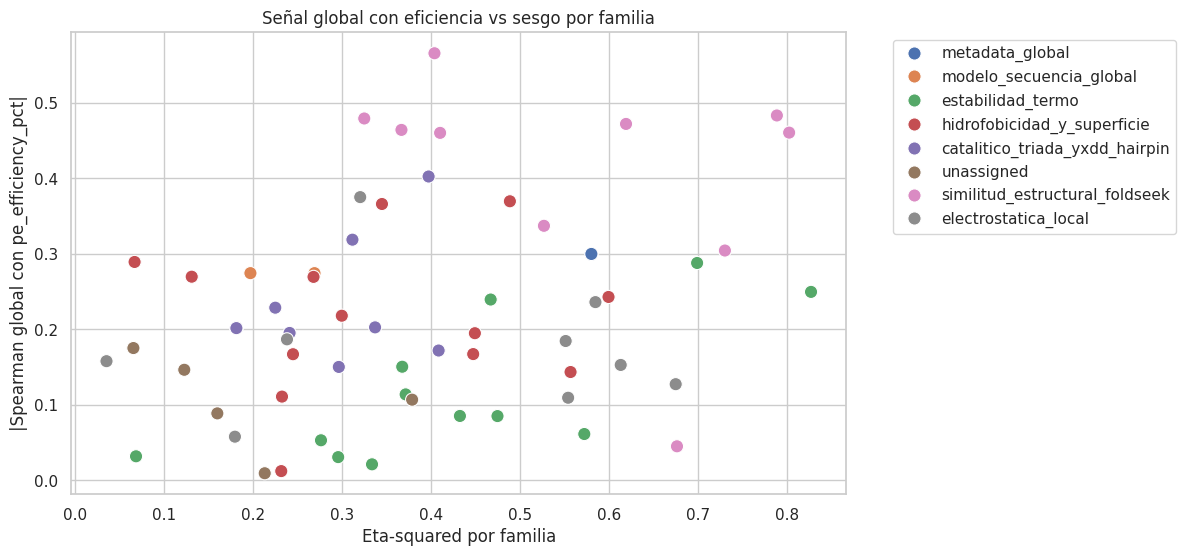

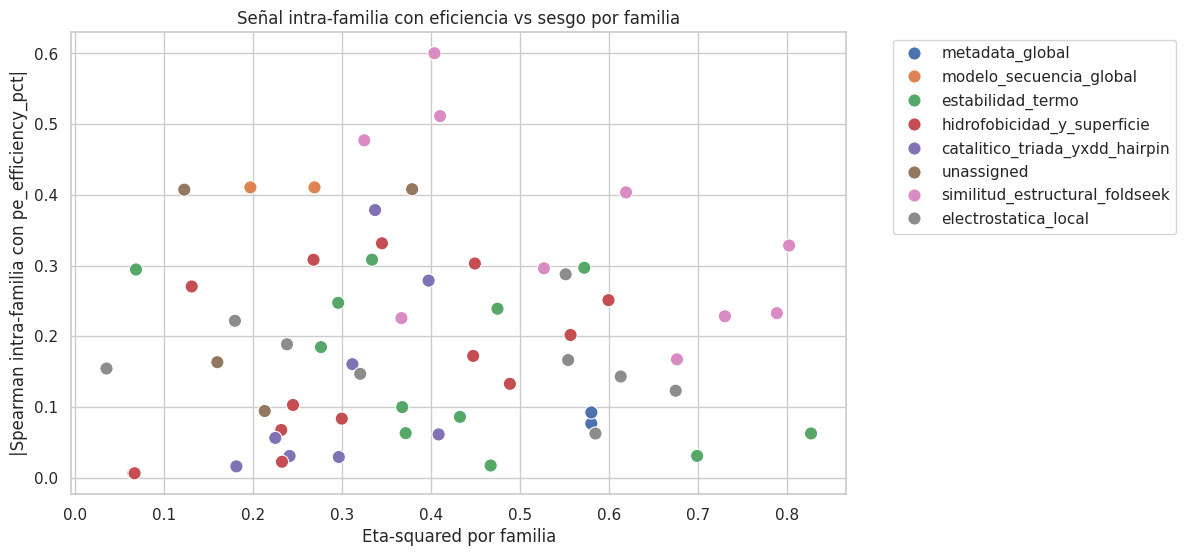

In [9]:
# ============================================================
# 8. VISUALIZACIONES PRE-MODELING
# ============================================================

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=feature_master_df,
    x="family_eta2",
    y="abs_eff_global",
    hue="block",
    s=90
)
plt.title("Señal global con eficiencia vs sesgo por familia")
plt.xlabel("Eta-squared por familia")
plt.ylabel("|Spearman global con pe_efficiency_pct|")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=feature_master_df,
    x="family_eta2",
    y="abs_eff_within_family",
    hue="block",
    s=90
)
plt.title("Señal intra-familia con eficiencia vs sesgo por familia")
plt.xlabel("Eta-squared por familia")
plt.ylabel("|Spearman intra-familia con pe_efficiency_pct|")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

# 9) Pruning por redundancia dentro de cada bloque

In [10]:
# ============================================================
# 9. PRUNING POR CORRELACION DENTRO DE CADA BLOQUE
# ============================================================
# Aquí reducimos variables casi duplicadas.
# Esto ayuda mucho en small data para evitar meter múltiples copias
# de la misma señal biológica.
# ============================================================

pruned_block_dict = {}
pruning_reports = {}

for block_name, cols in block_dict.items():
    num_cols = get_numeric_cols(train_df, cols)
    
    kept, decision_df = correlation_pruning(
        train_df,
        num_cols,
        threshold=0.95,
        prefer_df=candidate_df
    )
    
    pruned_block_dict[block_name] = kept
    pruning_reports[block_name] = decision_df
    
    print("=" * 100)
    print(f"Bloque: {block_name}")
    print(f"Original: {len(num_cols)} | Después de pruning: {len(kept)}")
    display(decision_df.head(20))

Bloque: metadata_global
Original: 3 | Después de pruning: 1


,keep,drop,corr
0,n_residues,protein_length_aa,0.999981
1,n_residues,seq_length,0.999981


Bloque: catalitico_triada_yxdd_hairpin
Original: 14 | Después de pruning: 11


,keep,drop,corr
1,yxdd_d1_is_turn,yxdd_d2_is_strand,1.000000
2,yxdd_d1_is_turn,yxdd_x_is_turn,1.000000
0,triad_best_rmsd,D1_D2_dist,0.979648


Bloque: hidrofobicidad_y_superficie
Original: 14 | Después de pruning: 12


...

,keep,drop,corr
1,t45_raw,t50_raw,0.969520
2,t65_raw,t70_raw,0.959088
0,t45_raw,t40_raw,0.957564


Bloque: similitud_estructural_foldseek
Original: 10 | Después de pruning: 9


,keep,drop,corr
0,foldseek_TM_MMLV,foldseek_TM_HIV1,0.996433


Bloque: modelo_secuencia_global
Original: 2 | Después de pruning: 1


,keep,drop,corr
0,perplexity,log_likelihood,0.950395


# 10) Resumen de bloques pruned

In [11]:
# ============================================================
# 10. RESUMEN DE BLOQUES DESPUES DE PRUNING
# ============================================================

pruned_summary_rows = []

for block_name, cols in pruned_block_dict.items():
    pruned_summary_rows.append({
        "block": block_name,
        "n_features_pruned": len(cols),
        "features": ", ".join(cols)
    })

pruned_summary_df = pd.DataFrame(pruned_summary_rows)
display(pruned_summary_df)

,block,n_features_pruned,features
0,metadata_global,1,n_residues
1,catalitico_triada_yxdd_hairpin,11,"D2_D3_dist, hairpin_confidence, hairpin_pass, ..."
2,hidrofobicidad_y_superficie,12,"hbonds_per_res, hydrophobic_per_res, nterm_avg..."
3,electrostatica_local,9,"connection_mean_pot, fingers_mean_pot, lpqg_sp..."
4,estabilidad_termo,9,"camsol, instability_index, t45_raw, t55_raw, t..."
5,similitud_estructural_foldseek,9,"foldseek_TM_Group2Intron, foldseek_TM_LTRRetro..."
6,modelo_secuencia_global,1,perplexity


# 11) Construcción de feature sets finales

In [12]:
# ============================================================
# 11. FEATURE SETS FINALES
# ============================================================
# Estos serán los grupos que luego se usarán en las ablaciones LOFO.
# ============================================================

features_metadata = pruned_block_dict.get("metadata_global", [])
features_catalytic = pruned_block_dict.get("catalitico_triada_yxdd_hairpin", [])
features_surface = pruned_block_dict.get("hidrofobicidad_y_superficie", [])
features_electro = pruned_block_dict.get("electrostatica_local", [])
features_stability = pruned_block_dict.get("estabilidad_termo", [])
features_foldseek = pruned_block_dict.get("similitud_estructural_foldseek", [])
features_seqmodel = pruned_block_dict.get("modelo_secuencia_global", [])

features_mechanistic = sorted(list(set(
    features_catalytic + features_surface + features_electro + features_stability
)))

features_non_foldseek = sorted(list(set(
    features_metadata + features_catalytic + features_surface + features_electro + features_stability + features_seqmodel
)))

features_all_pruned = sorted(list(set(
    features_metadata + features_catalytic + features_surface + features_electro + features_stability + features_foldseek + features_seqmodel
)))

feature_sets = {
    "metadata": features_metadata,
    "catalytic": features_catalytic,
    "surface": features_surface,
    "electro": features_electro,
    "stability": features_stability,
    "foldseek": features_foldseek,
    "seqmodel": features_seqmodel,
    "mechanistic": features_mechanistic,
    "non_foldseek": features_non_foldseek,
    "all_pruned": features_all_pruned,
    "catalytic_plus_surface": sorted(list(set(features_catalytic + features_surface))),
    "foldseek_plus_catalytic": sorted(list(set(features_foldseek + features_catalytic))),
    "foldseek_plus_mechanistic": sorted(list(set(features_foldseek + features_mechanistic))),
}

for set_name, feats in feature_sets.items():
    print(f"{set_name}: {len(feats)}")
    print(feats[:15], "..." if len(feats) > 15 else "")
    print("-" * 80)

metadata: 1
['n_residues'] 
--------------------------------------------------------------------------------
catalytic: 11
['D2_D3_dist', 'hairpin_confidence', 'hairpin_pass', 'triad_best_rmsd', 'triad_found_bin', 'yxdd_5A_mean_pot', 'yxdd_d1_is_turn', 'yxdd_hydrophobic_fraction', 'yxdd_mean_hydrophobicity', 'yxdd_std_hydrophobicity', 'yxdd_y_is_strand'] 
--------------------------------------------------------------------------------
surface: 12
['hbonds_per_res', 'hydrophobic_per_res', 'nterm_avg_sasa', 'pocket_hbonds_per_res', 'pocket_hydrophobic_per_res', 'pocket_mean_rsasa', 'sasa_per_res', 'whole_mean_hydrophobicity', 'whole_std_hydrophobicity', 'yxdd_hydrophobic_fraction', 'yxdd_mean_hydrophobicity', 'yxdd_std_hydrophobicity'] 
--------------------------------------------------------------------------------
electro: 9
['connection_mean_pot', 'fingers_mean_pot', 'lpqg_sp_3A_mean_pot', 'motif12_mean_pot', 'net_charge', 'overall_mean_pot', 'palm_mean_pot', 'thumb_mean_pot', 'yxdd_5

# 12) Tabla resumen de feature sets

In [13]:
# ============================================================
# 12. RESUMEN TABULAR DE FEATURE SETS
# ============================================================

feature_sets_df = pd.DataFrame({
    "feature_set_name": list(feature_sets.keys()),
    "n_features": [len(v) for v in feature_sets.values()],
    "features": [",".join(v) for v in feature_sets.values()]
})

display(feature_sets_df.sort_values("n_features", ascending=False))

,feature_set_name,n_features,features
9,all_pruned,48,"D2_D3_dist,camsol,connection_mean_pot,fingers_..."
12,foldseek_plus_mechanistic,46,"D2_D3_dist,camsol,connection_mean_pot,fingers_..."
8,non_foldseek,39,"D2_D3_dist,camsol,connection_mean_pot,fingers_..."
7,mechanistic,37,"D2_D3_dist,camsol,connection_mean_pot,fingers_..."
10,catalytic_plus_surface,20,"D2_D3_dist,hairpin_confidence,hairpin_pass,hbo..."
11,foldseek_plus_catalytic,20,"D2_D3_dist,foldseek_TM_Group2Intron,foldseek_T..."
2,surface,12,"hbonds_per_res,hydrophobic_per_res,nterm_avg_s..."
1,catalytic,11,"D2_D3_dist,hairpin_confidence,hairpin_pass,tri..."
3,electro,9,"connection_mean_pot,fingers_mean_pot,lpqg_sp_3..."
5,foldseek,9,"foldseek_TM_Group2Intron,foldseek_TM_LTRRetrot..."


# 13) Guardar artefactos para el pipeline


In [14]:
# ============================================================
# 13. GUARDAR ARTEFACTOS
# ============================================================
# Guardamos tablas para:
# - auditoría
# - inspección manual
# - debugging
# - reutilización en fases posteriores del notebook
# ============================================================

OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)

feature_master_df.to_csv(os.path.join(OUTPUT_DIR, "feature_master_df.csv"), index=False)
candidate_df.to_csv(os.path.join(OUTPUT_DIR, "feature_candidate_df.csv"), index=False)
pruned_summary_df.to_csv(os.path.join(OUTPUT_DIR, "pruned_block_summary.csv"), index=False)
feature_sets_df.to_csv(os.path.join(OUTPUT_DIR, "feature_sets_for_modeling.csv"), index=False)

with open(os.path.join(OUTPUT_DIR, "feature_sets_for_modeling.json"), "w") as f:
    json.dump(feature_sets, f, indent=2)

print("Artefactos guardados en:", OUTPUT_DIR)

Artefactos guardados en: /kaggle/working


# 14) Objetos finales listos para la siguiente fase

In [15]:
# ============================================================
# 14. OBJETOS LISTOS PARA MODELAMIENTO
# ============================================================

print("Objetos disponibles para la siguiente fase:")
print("- train_df")
print("- family_df")
print("- feat_dict_df")
print("- feature_master_df")
print("- candidate_df")
print("- pruned_block_dict")
print("- feature_sets")
print("- features_all_pruned")
print("- features_mechanistic")
print("- features_foldseek")
print("- features_catalytic")

Objetos disponibles para la siguiente fase:
- train_df
- family_df
- feat_dict_df
- feature_master_df
- candidate_df
- pruned_block_dict
- feature_sets
- features_all_pruned
- features_mechanistic
- features_foldseek
- features_catalytic


### ## Conclusión de la fase de preparación de features

En esta etapa se cargaron los datos base del reto, se reconstruyeron los bloques biológicos y se calcularon diagnósticos pre-modelado para distinguir entre señal global, señal intra-familia y sesgo por linaje evolutivo. Después se aplicó pruning por redundancia y se construyeron feature sets finales para las ablaciones del baseline LOFO.

A partir de aquí, el siguiente paso será definir una clase CFG y estructurar el pipeline de modelamiento:
- validación Leave-One-Family-Out
- preprocess / imputación
- entrenamiento de baselines
- comparación de feature sets
- generación de OOF y métricas

# MODELING AND AUTOMATION

## 1) Setup and Imports

In [16]:
# ============================================================
# RETROVIRAL WALL CHALLENGE
# NOTEBOOK 2: MODELING
# STAGE 1 - MODELING PIPELINE
# ============================================================

import os
import gc
import json
import math
import random
import warnings
warnings.filterwarnings("ignore")

from dataclasses import dataclass, field, asdict
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd

from sklearn.metrics import average_precision_score
from sklearn.model_selection import LeaveOneGroupOut

from scipy.stats import rankdata
from catboost import CatBoostClassifier, CatBoostRegressor

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Imports ready.")

Imports ready.


## 2) CFG 

In [17]:
# ============================================================
# CFG CENTRAL
# ============================================================
# Esta clase concentra:
# - paths
# - columnas base
# - feature set activo
# - parámetros de CV
# - parámetros de modelo
# - parámetros de inferencia y submission
# ============================================================

@dataclass
class CFG:
    seed: int = 42

    TRAIN_DIR: str = "/kaggle/input/datasets/damontoyat/retroviral-train"
    TEST_DIR: str = "/kaggle/input/datasets/damontoyat/retroviral-test"
    FAMILY_DIR: str = "/kaggle/input/datasets/damontoyat/retroviral-family-splits"
    FEAT_DICT_DIR: str = "/kaggle/input/datasets/damontoyat/retroviral-feature-dic"

    train_filename: str = "train.csv"
    test_filename: str = "test.csv"
    family_filename: str = "family_splits.csv"
    feat_dict_filename: str = "feature_dictionary.csv"

    feature_sets_json_path: str = "/kaggle/working/feature_sets_for_modeling.json"
    feature_master_csv_path: str = "/kaggle/working/feature_master_df.csv"

    output_dir: str = "/kaggle/working"

    id_col: str = "rt_name"
    seq_col: str = "sequence"
    family_col: str = "rt_family"

    target_class: str = "active"
    target_reg: str = "pe_efficiency_pct"

    cv_name: str = "LOFO"
    use_lofo: bool = True

    # importante: ahora usaremos ensemble de feature sets
    ensemble_feature_sets: List[str] = field(default_factory=lambda: [
        "foldseek",
        "foldseek_plus_catalytic",
        "foldseek_plus_mechanistic"
    ])

    imputer_strategy: str = "median"
    add_missing_indicators: bool = False

    classifier_name: str = "catboost"
    regressor_name: str = "catboost"

    # CatBoost classifier
    cb_cls_iterations: int = 500
    cb_cls_depth: int = 4
    cb_cls_learning_rate: float = 0.03
    cb_cls_l2_leaf_reg: float = 5.0
    cb_cls_loss_function: str = "Logloss"
    cb_cls_eval_metric: str = "AUC"
    cb_verbose: bool = False

    # CatBoost regressor
    cb_reg_iterations: int = 500
    cb_reg_depth: int = 4
    cb_reg_learning_rate: float = 0.03
    cb_reg_l2_leaf_reg: float = 5.0
    cb_reg_loss_function: str = "RMSE"

    reg_train_mode: str = "all_rows"
    use_log1p_reg_target: bool = True

    reg_clip_min: float = 0.0
    reg_clip_max: float = 41.0

    cls_blend_weight: float = 0.35
    reg_blend_weight: float = 0.65

    submission_id_col: str = "rt_name"
    submission_pred_col: str = "predicted_score"
    submission_filename: str = "submission_catboost_foldseek_ensemble.csv"

    verbose: bool = True

## 3) Instantiate CFG

In [18]:
cfg = CFG()

print("CFG cargada.")
print(pd.Series(asdict(cfg)))

CFG cargada.
seed                                                                      42
TRAIN_DIR                  /kaggle/input/datasets/damontoyat/retroviral-t...
TEST_DIR                   /kaggle/input/datasets/damontoyat/retroviral-test
FAMILY_DIR                 /kaggle/input/datasets/damontoyat/retroviral-f...
FEAT_DICT_DIR              /kaggle/input/datasets/damontoyat/retroviral-f...
train_filename                                                     train.csv
test_filename                                                       test.csv
family_filename                                            family_splits.csv
feat_dict_filename                                    feature_dictionary.csv
feature_sets_json_path        /kaggle/working/feature_sets_for_modeling.json
feature_master_csv_path                /kaggle/working/feature_master_df.csv
output_dir                                                   /kaggle/working
id_col                                                         

# 4) Basic Utilities

In [19]:
# ============================================================
# BASIC UTILITIES
# ============================================================

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(cfg.seed)
print("Seed fixed.")

Seed fixed.


# 5) Paths and Data Loading

In [20]:
# ============================================================
# PATHS AND DATA LOADING
# ============================================================

def build_paths(cfg: CFG) -> Dict[str, str]:
    return {
        "train_path": os.path.join(cfg.TRAIN_DIR, cfg.train_filename),
        "test_path": os.path.join(cfg.TEST_DIR, cfg.test_filename),
        "family_path": os.path.join(cfg.FAMILY_DIR, cfg.family_filename),
        "feat_dict_path": os.path.join(cfg.FEAT_DICT_DIR, cfg.feat_dict_filename),
    }

def load_data(cfg: CFG) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    paths = build_paths(cfg)
    
    train_df = pd.read_csv(paths["train_path"])
    test_df = pd.read_csv(paths["test_path"])
    family_df = pd.read_csv(paths["family_path"])
    feat_dict_df = pd.read_csv(paths["feat_dict_path"])
    
    if cfg.verbose:
        print("train_df:", train_df.shape)
        print("test_df:", test_df.shape)
        print("family_df:", family_df.shape)
        print("feat_dict_df:", feat_dict_df.shape)
    
    return train_df, test_df, family_df, feat_dict_df

train_df, test_df, family_df, feat_dict_df = load_data(cfg)

train_df: (57, 71)
test_df: (57, 69)
family_df: (7, 5)
feat_dict_df: (66, 2)


# 6) Load Feature Sets

In [21]:
# ============================================================
# LOAD FEATURE SETS
# ============================================================

def load_feature_sets(cfg: CFG) -> Dict[str, List[str]]:
    if not os.path.exists(cfg.feature_sets_json_path):
        raise FileNotFoundError(
            f"No encontré {cfg.feature_sets_json_path}. "
            "Primero corre la etapa de Feature Preparation and Pre-modeling Diagnostics."
        )
    
    with open(cfg.feature_sets_json_path, "r") as f:
        feature_sets = json.load(f)
    
    if cfg.verbose:
        print("Feature sets cargados:")
        for k, v in feature_sets.items():
            print(f"{k}: {len(v)}")
    
    return feature_sets

feature_sets = load_feature_sets(cfg)

Feature sets cargados:
metadata: 1
catalytic: 11
surface: 12
electro: 9
stability: 9
foldseek: 9
seqmodel: 1
mechanistic: 37
non_foldseek: 39
all_pruned: 48
catalytic_plus_surface: 20
foldseek_plus_catalytic: 20
foldseek_plus_mechanistic: 46


# 8) Model Builders

In [22]:
# ============================================================
# MODEL BUILDERS
# ============================================================

def build_classifier(cfg: CFG):
    if cfg.classifier_name == "catboost":
        model = CatBoostClassifier(
            iterations=cfg.cb_cls_iterations,
            depth=cfg.cb_cls_depth,
            learning_rate=cfg.cb_cls_learning_rate,
            l2_leaf_reg=cfg.cb_cls_l2_leaf_reg,
            loss_function=cfg.cb_cls_loss_function,
            eval_metric=cfg.cb_cls_eval_metric,
            random_seed=cfg.seed,
            verbose=cfg.cb_verbose
        )
        return model
    else:
        raise ValueError(f"Unsupported classifier_name: {cfg.classifier_name}")


def build_regressor(cfg: CFG):
    if cfg.regressor_name == "catboost":
        model = CatBoostRegressor(
            iterations=cfg.cb_reg_iterations,
            depth=cfg.cb_reg_depth,
            learning_rate=cfg.cb_reg_learning_rate,
            l2_leaf_reg=cfg.cb_reg_l2_leaf_reg,
            loss_function=cfg.cb_reg_loss_function,
            random_seed=cfg.seed,
            verbose=cfg.cb_verbose
        )
        return model
    else:
        raise ValueError(f"Unsupported regressor_name: {cfg.regressor_name}")

# 9) Metrics, Ranking, and Feature Set Resolution

In [23]:
# ============================================================
# METRICS, RANKING, AND FEATURE SET RESOLUTION
# ============================================================

def safe_pr_auc(y_true, y_prob):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    if len(np.unique(y_true)) < 2:
        return np.nan
    return average_precision_score(y_true, y_prob)


def clip_regression_preds(preds, cfg: CFG):
    return np.clip(preds, cfg.reg_clip_min, cfg.reg_clip_max)


def to_rank01(x):
    x = np.asarray(x)
    return rankdata(x, method="average") / len(x)


def blend_rank_scores(p_active, reg_pred, cfg: CFG):
    rank_cls = to_rank01(p_active)
    rank_reg = to_rank01(reg_pred)
    return cfg.cls_blend_weight * rank_cls + cfg.reg_blend_weight * rank_reg


def resolve_one_feature_set(
    feature_set_name: str,
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    feature_sets: Dict[str, List[str]]
) -> List[str]:
    if feature_set_name not in feature_sets:
        raise ValueError(f"{feature_set_name} does not exist in feature_sets.")

    feats = feature_sets[feature_set_name]
    feats = [c for c in feats if c in train_df.columns and c in test_df.columns]
    feats = [c for c in feats if pd.api.types.is_numeric_dtype(train_df[c])]

    if len(feats) == 0:
        raise ValueError(f"No valid features remained for {feature_set_name}.")

    return feats

# 10) Optional LOFO Diagnostics

In [24]:
# ============================================================
# OPTIONAL LOFO DIAGNOSTICS
# ============================================================

def get_lofo_splits(df: pd.DataFrame, cfg: CFG):
    logo = LeaveOneGroupOut()
    groups = df[cfg.family_col].values
    splits = list(logo.split(df, groups=groups))

    if cfg.verbose:
        print(f"Number of LOFO folds: {len(splits)}")
        print("Families:")
        print(df[cfg.family_col].value_counts())

    return splits

## 11) Single Feature Set Full-Train Inference

In [25]:
# ============================================================
# SINGLE FEATURE SET FULL-TRAIN INFERENCE
# ============================================================

def fit_full_and_predict_test_single_feature_set(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    features: List[str],
    cfg: CFG,
    feature_set_name: str
):
    X_train = train_df[features].copy()
    X_test = test_df[features].copy()

    y_cls = train_df[cfg.target_class].copy()
    y_reg = train_df[cfg.target_reg].copy()

    # Classifier
    cls_model = build_classifier(cfg)
    cls_model.fit(X_train, y_cls)
    test_p_active = cls_model.predict_proba(X_test)[:, 1]

    # Regressor
    reg_model = build_regressor(cfg)

    if cfg.reg_train_mode == "positives_only":
        mask = train_df[cfg.target_class] == 1
        X_train_reg = train_df.loc[mask, features]
        y_train_reg = train_df.loc[mask, cfg.target_reg].copy()
    elif cfg.reg_train_mode == "all_rows":
        X_train_reg = X_train
        y_train_reg = y_reg.copy()
    else:
        raise ValueError(f"Unsupported reg_train_mode: {cfg.reg_train_mode}")

    if cfg.use_log1p_reg_target:
        y_train_reg_fit = np.log1p(y_train_reg)
    else:
        y_train_reg_fit = y_train_reg

    reg_model.fit(X_train_reg, y_train_reg_fit)
    test_reg = reg_model.predict(X_test)

    if cfg.use_log1p_reg_target:
        test_reg = np.expm1(test_reg)

    test_reg = clip_regression_preds(test_reg, cfg)
    test_score = blend_rank_scores(test_p_active, test_reg, cfg)

    pred_df = test_df[[cfg.id_col]].copy()
    pred_df["feature_set"] = feature_set_name
    pred_df["p_active"] = test_p_active
    pred_df["reg_pred"] = test_reg
    pred_df["predicted_score"] = test_score

    model_bundle = {
        "classifier": cls_model,
        "regressor": reg_model,
        "features": features,
        "feature_set_name": feature_set_name,
        "cfg": asdict(cfg),
    }

    return pred_df, model_bundle

## 12) — Ensemble Inference

In [26]:
# ============================================================
# ENSEMBLE INFERENCE
# ============================================================

def fit_ensemble_and_predict_test(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    feature_sets_dict: Dict[str, List[str]],
    cfg: CFG
):
    pred_dfs = []
    model_bundles = []

    for fs_name in cfg.ensemble_feature_sets:
        feats = resolve_one_feature_set(fs_name, train_df, test_df, feature_sets_dict)

        if cfg.verbose:
            print(f"Training feature set: {fs_name} | n_features={len(feats)}")

        pred_df_fs, bundle_fs = fit_full_and_predict_test_single_feature_set(
            train_df=train_df,
            test_df=test_df,
            features=feats,
            cfg=cfg,
            feature_set_name=fs_name
        )

        pred_dfs.append(pred_df_fs)
        model_bundles.append(bundle_fs)

    base = test_df[[cfg.id_col]].copy()

    for pred_df_fs in pred_dfs:
        fs_name = pred_df_fs["feature_set"].iloc[0]
        base = base.merge(
            pred_df_fs[[cfg.id_col, "predicted_score"]].rename(
                columns={"predicted_score": f"score_{fs_name}"}
            ),
            on=cfg.id_col,
            how="left"
        )

    score_cols = [c for c in base.columns if c.startswith("score_")]
    base["predicted_score"] = base[score_cols].mean(axis=1)

    return base, model_bundles, pred_dfs

## 13 — Save Ensemble Artifacts

In [27]:
# ============================================================
# SAVE ENSEMBLE ARTIFACTS
# ============================================================

def save_ensemble_artifacts(
    ensemble_test_pred_df: pd.DataFrame,
    raw_pred_dfs: List[pd.DataFrame],
    cfg: CFG
):
    os.makedirs(cfg.output_dir, exist_ok=True)

    ensemble_test_pred_df.to_csv(
        os.path.join(cfg.output_dir, "ensemble_test_predictions.csv"),
        index=False
    )

    for pred_df in raw_pred_dfs:
        fs_name = pred_df["feature_set"].iloc[0]
        pred_df.to_csv(
            os.path.join(cfg.output_dir, f"test_predictions_{fs_name}.csv"),
            index=False
        )

    print("Ensemble artifacts saved.")

## 14) Final Submission Generation

In [28]:
# ============================================================
# FINAL SUBMISSION GENERATION
# ============================================================

ensemble_test_pred_df, ensemble_model_bundles, raw_pred_dfs = fit_ensemble_and_predict_test(
    train_df=train_df,
    test_df=test_df,
    feature_sets_dict=feature_sets,
    cfg=cfg
)

save_ensemble_artifacts(ensemble_test_pred_df, raw_pred_dfs, cfg)

submission_df = ensemble_test_pred_df[[cfg.id_col, "predicted_score"]].copy()
submission_df.columns = [cfg.submission_id_col, cfg.submission_pred_col]

submission_path = os.path.join(cfg.output_dir, cfg.submission_filename)
submission_df.to_csv(submission_path, index=False)

display(submission_df.head())
print("Submission saved to:", submission_path)

Training feature set: foldseek | n_features=9
Training feature set: foldseek_plus_catalytic | n_features=20
Training feature set: foldseek_plus_mechanistic | n_features=46
Ensemble artifacts saved.


,rt_name,predicted_score
0,A.platensis-Cas1-RT,0.249123
1,CRISPRRT2-RT,0.319883
2,FuRT-Cas1-RT,0.523684
3,Med-CasRT,0.293275
4,ROSE-CRISPR-RT,0.275439


Submission saved to: /kaggle/working/submission_catboost_foldseek_ensemble.csv
